In [2]:
# !pip install --upgrade pip
!pip install qdrant-client transformers torch torchaudio librosa numpy musicbrainzngs
pip install syncedlyrics "qdrant-client[fastembed]>=1.14.2" mutagen

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 9.7 MB/s eta 0:00:00


In [1]:
from init_utils import FileProcessor, LyricsDB
from qdrant_client import QdrantClient, models
import json
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
qd_client = QdrantClient("http://localhost:6333")
fp = FileProcessor()

In [ ]:
data = fp.process_folder("S:\Music", better_lyrics_quality=False)
fp.to_json('test_metadata.json')
# with open ('metadata.json', 'r', encoding='utf-8') as f_in:
#     data = json.load(f_in)

Найдено файлов: 5770, воркеров: 8


  0%|          | 0/5770 [00:00<?, ?it/s]

An error occurred while searching for an LRC on Lrclib
HTTPSConnectionPool(host='lrclib.net', port=443): Read timed out. (read timeout=10)


3 ['作曲 ', ' Kanye West/Keith Harris/William Adams\n作曲 ', ' William Adams/Kanye West/Keith Harris\nJust another one champion sound\nYeah, Estelle, we \'bout to get down (get down)\nWho the hottest in the world right now\nJust touched down in London town\nBet they give me a pound\nTell them put the money in my hand right now\nTell the promoter we need more seats\nWe just sold out all the floor seats\nTake me on a trip, I\'d like to go someday\nTake me to New York, I\'d love to see L.A.\nI really want to come kick it with you\nYou\'ll be my American boy\nHe said "Hey, sister, it\'s really, really nice to meet you"\nI just met this 5 foot 7 guy who\'s just my type\nI like the way he\'s speaking, his confidence is peaking\nDon\'t like his baggy jeans\nBut I\'mma like what\'s underneath them\nAnd no I ain\'t been to M.I.A\nI heard that Cali never rains and New York\'s heart awaits\nFirst let\'s see the west end, I\'ll show you to my brethren\nI\'m liking this American boy, American boy\nTake

An error occurred while searching for an LRC on Lrclib
HTTPSConnectionPool(host='lrclib.net', port=443): Read timed out. (read timeout=10)


## data_postprocessing

In [6]:
import pandas as pd

In [7]:
data_to_df = list(data.values())
df = pd.DataFrame(data_to_df)

In [8]:
df = df[df['duration'] <= 420]

In [15]:
iqr = (df['duration'].quantile(q=0.5) - df['duration'].quantile(q=0.25))

In [16]:
q3 = df['duration'].quantile(q=0.25)
q2 = df['duration'].quantile(q=0.5)
q1 = df['duration'].quantile(q=0.75)

In [17]:
df.loc[df['duration']<(q3-1.5*iqr), 'duration_new'] = f'0-{int(round(q3-1.5*iqr, 0))}'
df.loc[(df['duration']>=(q3-1.5*iqr))&(df['duration']<q3), 'duration_new'] = f'{int(round(q3-1.5*iqr, 0))}-{int(round(q3, 0))}'
df.loc[(df['duration']>=q3)&(df['duration']<q2), 'duration_new'] = f'{int(round(q3, 0))}-{int(round(q2, 0))}'
df.loc[(df['duration']>=q2)&(df['duration']<=q1), 'duration_new'] = f'{int(round(q2, 0))}-{int(round(q1))}'
df.loc[(df['duration']>=q1)&(df['duration']<=(q1+1.5*iqr)), 'duration_new'] = f'{int(round(q1, 0))}-{int(round(q1+1.5*iqr, 0))}'
df.loc[df['duration']>q1+1.5*iqr, 'duration_new'] = f"{int(round(q1+1.5*iqr, 0))}-{int(df['duration'].max())}"

<BarContainer object of 6 artists>

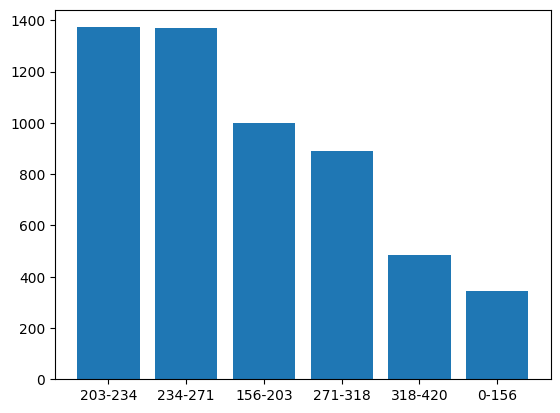

In [18]:
plt.bar(x=df['duration_new'].value_counts().index, height=df['duration_new'].value_counts().values)

In [36]:
df.drop(labels='duration', axis=1, inplace=True)
df.rename(columns={'duration_new': 'duration'}, inplace=True)


In [5]:
import musicbrainzngs

In [11]:
musicbrainzngs.set_useragent("MusicMetadataFetcher", "1.0", "your@email.com")

In [54]:
res = musicbrainzngs.search_recordings(artist='Kanye West', recording='Stronger', limit=1)

In [55]:
recordings = res.get("recording-list", [])
if recordings:
    rec = recordings[0]

In [52]:
res

{'recording-list': [{'id': '0ed10d44-0bed-4399-a504-fbf4f72c7a6b',
   'ext:score': '100',
   'title': 'Power',
   'length': '287080',
   'artist-credit': [{'name': 'Kanye West',
     'artist': {'id': '164f0d73-1234-4e2c-8743-d77bf2191051',
      'name': 'Ye',
      'sort-name': 'Ye',
      'disambiguation': 'formerly Kanye West',
      'alias-list': [{'locale': 'zh',
        'sort-name': 'West, Kanye',
        'type': 'Artist name',
        'primary': 'primary',
        'alias': 'Kanye West'},
       {'locale': 'en',
        'sort-name': 'West, Kanye Omari',
        'type': 'Legal name',
        'begin-date': '1977-06-08',
        'end-date': '2021-10-18',
        'alias': 'Kanye Omari West'},
       {'sort-name': 'Ye',
        'type': 'Legal name',
        'begin-date': '2021-10-18',
        'alias': 'Ye'},
       {'sort-name': 'Yeezy', 'type': 'Artist name', 'alias': 'Yeezy'},
       {'sort-name': 'Kanye', 'type': 'Artist name', 'alias': 'Kanye'},
       {'sort-name': 'Kayne West',
 

## DB creation

In [5]:
qd_client.delete_collection("test")

True

In [6]:
db = LyricsDB(qd_client, "test")
db.fit(data)

Loading weights:   0%|          | 0/46 [00:00<?, ?it/s]

BertModel LOAD REPORT from: jinaai/jina-embeddings-v2-small-en
Key                                                  | Status     | 
-----------------------------------------------------+------------+-
encoder.layer.{0, 1, 2, 3}.mlp.layernorm.weight      | UNEXPECTED | 
encoder.layer.{0, 1, 2, 3}.mlp.wo.bias               | UNEXPECTED | 
encoder.layer.{0, 1, 2, 3}.mlp.layernorm.bias        | UNEXPECTED | 
encoder.layer.{0, 1, 2, 3}.mlp.gated_layers.weight   | UNEXPECTED | 
encoder.layer.{0, 1, 2, 3}.mlp.wo.weight             | UNEXPECTED | 
embeddings.position_embeddings.weight                | MISSING    | 
encoder.layer.{0, 1, 2, 3}.intermediate.dense.weight | MISSING    | 
encoder.layer.{0, 1, 2, 3}.intermediate.dense.bias   | MISSING    | 
encoder.layer.{0, 1, 2, 3}.output.LayerNorm.weight   | MISSING    | 
encoder.layer.{0, 1, 2, 3}.output.dense.bias         | MISSING    | 
encoder.layer.{0, 1, 2, 3}.output.dense.weight       | MISSING    | 
encoder.layer.{0, 1, 2, 3}.output.LayerN

Collection test has been successfully created


  0%|          | 0/1 [00:00<?, ?it/s]

Data was fitted in DB successfully


In [10]:
db.search("Raye about sad", limit=3)

[ScoredPoint(id='10680431-7f00-4b0a-a03d-97e01bf4c212', version=1, score=1.0, payload={'lyrics': "One, and two, and three\nAnd, mmm\nHennessy, I'ma need this liquid courage\nAll of it, oh, yeah\nAnd I seen a man, seen a man\nSat at the bar, oh, yeah\nAnd for a while, I'ma kiss goodbye to my worries\nAll of 'em, oh, yeah\nNo dinner, man, I started seein' the stars, oh\nThe sad, sad way to learn how\nSkirt's too short, I got my curves out\nI'm a little too lit, so call the last round\nI get all dressed up\nTo go ahead, let myself down\nSo you could just hold me like my dress, skin-tight\nWe could pretend this is Saturday night\nAnd it's alright, it's alright, mmm\nSo tell me who's next up? (Tell me who's next up)\nTo come on here and waste my time, mmm (to come on here and waste my time)\nSo you could just hold me like my dress, skin-tight\nCould we pretend this is Saturday night?\nIt's alright, it's alright\nIt's alright, yeah-yeah\nI'm about to tell you I think you're funny\nOh, honey,

## Classic embeddings

Попробую чанковать на абзацы и уникально это делать

In [5]:
genre_map = {
    # Pop
    'pop': 'Pop', 'поп': 'Pop', 'dance-pop': 'Pop', 'indie pop': 'Pop',
    'art pop': 'Pop', 'adult contemporary': 'Pop', 'bubblegum': 'Pop',
    'instrumental pop': 'Pop', 'pop/indie': 'Pop', 'alternative pop': 'Pop',

    # Rock
    'rock': 'Rock', 'classic rock': 'Rock', 'hard rock': 'Rock',
    'indie rock': 'Rock', 'alternative rock': 'Rock', 'alt. rock': 'Rock',
    'pop rock': 'Rock', 'blues rock': 'Rock', 'grunge': 'Rock',
    'post-grunge': 'Rock', 'post grunge': 'Rock', 'progressive rock': 'Rock',
    'album rock': 'Rock', 'soft rock': 'Rock', 'pop-rock': 'Rock',
    'pop/rock': 'Rock', 'blues/pop rock': 'Rock', 'dance-punk': 'Rock',
    'acid punk': 'Rock', 'stoner rock': 'Rock', 'alternative metal': 'Rock',
    'nu metal': 'Nu-Metal',

    # Electronic
    'electronic': 'Electronic', 'synthpop': 'Electronic', 'synth-pop': 'Electronic',
    'electro': 'Electronic', 'electro house': 'Electronic', 'french house': 'Electronic',
    'house': 'Electronic', 'progressive house': 'Electronic', 'dubstep': 'Electronic',
    'brostep': 'Electronic', 'eurodance': 'Electronic', 'club': 'Electronic',
    'downtempo': 'Electronic', 'ambient': 'Electronic', 'nu-disco': 'Electronic',
    'disco': 'Electronic', 'trance': 'Electronic', 'dance & dj': 'Electronic',
    'club/dance': 'Electronic',

    # Hip-Hop
    'hip hop': 'Hip-Hop', 'rap': 'Hip-Hop', 'hip-hop': 'Hip-Hop',
    'east coast hip hop': 'Hip-Hop', 'alternative hip hop': 'Hip-Hop',

    # R&B / Soul
    'r&b': 'R&B/Soul', 'soul': 'R&B/Soul', 'contemporary r&b': 'R&B/Soul',
    'alternative r&b': 'R&B/Soul', 'funk': 'R&B/Soul', 'boogie': 'R&B/Soul',
    'r&b/soul': 'R&B/Soul', 'acid jazz': 'R&B/Soul',

    # Alternative
    'alternative': 'Alternative', 'new wave': 'Alternative', 'indie': 'Alternative',
    'goth rock': 'Alternative', 'experimental': 'Alternative',
    'alternative & indie': 'Alternative',

    # Dance (самостоятельный)
    'dance': 'Dance',

    # Blues
    'blues': 'Blues',

    # Soundtrack
    'soundtrack': 'Soundtrack',
}

NOISE = {'none', 'miscellaneous', 'abstract', 'aggressive', '00s', '80s',
         '5+ wochen', 'adam levine', 'country & folk', 'электронная музыка',
         'pop, miscellaneous', 'pop soul r&b'}


In [7]:
data

{'Sohodolls — Bang Bang Bang Bang': {'title': 'Bang Bang Bang Bang',
  'artist': 'Sohodolls',
  'album': 'Ribbed Music For The Numb Generation',
  'year': 2007,
  'genre': 'pop',
  'duration': 182,
  'lyrics': "Teacher says that I've been naughty\nI must learn to concentrate\nBut the girls they pull my hair\nAnd with the boys, I can't relate\nDaddy says I'm good for nothing\nMama says that it's from him\nManic sister thinks I'm cracking\nBrother says it's in my genes\n\n(Oh-oh, oh-oh)\nDon't you want to?\nDon't you want to be the one? (Oh-oh, oh-oh)\nDon't you want to?\nBang, bang, bang, bang, bang, bang, bang\n\n(Oh-oh, oh-oh)\nDon't you want to?\nDon't you want to hold the gun? (Oh-oh, oh-oh)\nDon't you want to?\nBang, bang, bang, bang, bang, bang, bang\n\nSo we put on our eyeliner\nAnd a bit of glitter dust\nLife at night is always finer\nNeon streets are full of lust\nTeenage kids and Soho Dolls\nThey make you want to cry, ay-ay\nLike my superstar, they fall\nSome will be alright\n

In [20]:
qd_client.create_collection(
    collection_name="lyrics-hybrid-chuncked",
    vectors_config={
        # Named dense vector for jinaai/jina-embeddings-v2-small-en
        "jina-base-chunked": models.VectorParams(
            size=512,
            distance=models.Distance.COSINE,
        ),
    },
    sparse_vectors_config={
        "bm25": models.SparseVectorParams(
            modifier=models.Modifier.IDF,
        )
    }
)

True

In [18]:
import numpy as np
import uuid
import re
from qdrant_client import models
from sentence_transformers import SentenceTransformer
model_name: str = "jinaai/jina-embeddings-v2-small-en"
model = SentenceTransformer(model_name)

def chunks_to_embedding(chunks: list[str]) -> list[float]:
    """
    Получить один усреднённый эмбеддинг из списка чанков.
    Взвешивание по количеству токенов (апроксимируем длиной строки).
    """
    if not chunks:
        raise ValueError("chunks list is empty")

    # Получаем эмбеддинги через Qdrant inference (тот же подход что и в upsert)
    # Если у тебя есть отдельный encoder — замени на него

    
    embeddings = model.encode(chunks, normalize_embeddings=True)  # shape: (n_chunks, 1024)
    weights = np.array([len(c) for c in chunks], dtype=np.float32)
    weights /= weights.sum()
    
    averaged = np.average(embeddings, axis=0, weights=weights)
    
    # L2-нормализация результата (важно для cosine similarity)
    averaged /= np.linalg.norm(averaged)
    
    return averaged.tolist()

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\ivans\anaconda3\envs\lyrics-search\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ivans\.cache\huggingface\hub\models--jinaai--jina-embeddings-v2-small-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [21]:
def upsert_in_batches(client, collection_name, points, batch_size=100):
    for i in range(0, len(points), batch_size):
        batch = points[i:i + batch_size]
        client.upsert(
            collection_name=collection_name,
            points=batch
        )
        print(f"Upserted {min(i + batch_size, len(points))}/{len(points)}")

In [22]:
upsert_in_batches(
    qd_client,
    collection_name="lyrics-hybrid-chuncked",
    points=[
        models.PointStruct(
            id=uuid.uuid4().hex,
            vector={
                "bm25": models.Document(
                    text=song_info["lyrics"],
                    model="Qdrant/bm25",
                ),
                # Усреднённый эмбеддинг из чанков — передаём как plain вектор
                "jina-base-chunked": chunks_to_embedding(song_info["lyrics_chunked"]),
            },
            payload={
                "lyrics":    song_info["lyrics"],
                "title":     song_info["title"],
                "artist":    song_info["artist"],
                "album":     song_info["album"],
                "year":      song_info.get("year"),
                "genre":     _normalize_genre(song_info.get("genre")),
                "duration":  song_info.get("duration")
            }
        )
        for song_info in result
    ]
)

Upserted 100/5466
Upserted 200/5466
Upserted 300/5466
Upserted 400/5466
Upserted 500/5466
Upserted 600/5466
Upserted 700/5466
Upserted 800/5466
Upserted 900/5466
Upserted 1000/5466
Upserted 1100/5466
Upserted 1200/5466
Upserted 1300/5466
Upserted 1400/5466
Upserted 1500/5466
Upserted 1600/5466
Upserted 1700/5466
Upserted 1800/5466
Upserted 1900/5466
Upserted 2000/5466
Upserted 2100/5466
Upserted 2200/5466
Upserted 2300/5466
Upserted 2400/5466
Upserted 2500/5466
Upserted 2600/5466
Upserted 2700/5466
Upserted 2800/5466
Upserted 2900/5466
Upserted 3000/5466
Upserted 3100/5466
Upserted 3200/5466
Upserted 3300/5466
Upserted 3400/5466
Upserted 3500/5466
Upserted 3600/5466
Upserted 3700/5466
Upserted 3800/5466
Upserted 3900/5466
Upserted 4000/5466
Upserted 4100/5466
Upserted 4200/5466
Upserted 4300/5466
Upserted 4400/5466
Upserted 4500/5466
Upserted 4600/5466
Upserted 4700/5466
Upserted 4800/5466
Upserted 4900/5466
Upserted 5000/5466
Upserted 5100/5466
Upserted 5200/5466
Upserted 5300/5466
Up

In [82]:
# def multi_stage_search(query: str, limit: int = 1) -> list[models.ScoredPoint]:
#     results = qd_client.query_points(
#         collection_name="lyrics-hybrid-chuncked",
#         prefetch=[
#             models.Prefetch(
#                 query=models.Document(
#                     text=query,
#                     model="jinaai/jina-embeddings-v2-small-en",
#                 ),
#                 using="jina-base-chunked",
#                 # Prefetch ten times more results, then
#                 # expected to return, so we can really rerank
#                 limit=(10 * limit),
#             ),
#         ],
#         query=models.Document(
#             text=query,
#             model="Qdrant/bm25", 
#         ),
#         using="bm25",
#         limit=limit,
#         with_payload=True,
#     )

#     return results.points

def rrf_search(query: str, limit: int = 1) -> list[models.ScoredPoint]:
    results = qd_client.query_points(
        collection_name="lyrics-hybrid-chuncked",
        prefetch=[
            models.Prefetch(
                query=models.Document(
                    text=query,
                    model="jinaai/jina-embeddings-v2-small-en",
                ),
                using="jina-base-chunked",
                limit=(1* limit),
            ),
            models.Prefetch(
                query=models.Document(
                    text=query,
                    model="Qdrant/bm25",
                ),
                using="bm25",
                limit=(5 * limit),
            ),
        ],
        # Fusion query enables fusion on the prefetched results
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        with_payload=True,
    )
    return results.points

In [83]:
rrf_search('Kanye West Roses')

[ScoredPoint(id='37f73d32-d4ac-449d-a3cd-a67e5580125d', version=36, score=0.5, payload={'lyrics': "作词 : Peake, Ryan Anthony / Kroeger, Brandon Henry / Kroeger, Michael Douglas Henry / Kroeger, Chad\n作曲 : Peake, Ryan Anthony / Kroeger, Brandon Henry / Kroeger, Michael Douglas Henry / Kroeger, Chad\n[00:17.67]Children all have saviors\n[00:21.06]Children don't care who saves us\n[00:30.00]Round the corner, round the bend\n[00:30.69]Fingernails torn to the end\n[00:35.88]Bring back, bring back\n[00:43.98]Bring back, bring back on me\n[00:45.78]On me\n[00:46.26]I told them, we scold them\n[01:06.09]Can't console them always\n[01:11.61]Toy soldiers falling\n[01:12.81]Dominoes, but who knows?\n[01:26.94]Bring back, bring back\n[01:28.71]Bring back, bring back on me\n[01:29.79]On me\n[01:49.59]Yeah and I dream of falling stars\n[02:21.84]And tokes for all my friends\n[02:25.95]And I will live forever\n[02:29.49]Yeah and I dream of all I'm worth\n[03:03.72]And all along the way\n[03:07.92]And 

In [77]:
results = multi_stage_search("ferrari", limit = 5)
print(f"Найдено {len(results)} результатов")
if results:
    print(f"Самый релевантный результат: {results[0].payload['artist']} - {results[0].payload['title']}")

Найдено 4 результатов
Самый релевантный результат: Roddy Ricch - Underdog


In [83]:
results[0].payload

{'lyrics': 'Slide out the garage (Roof)\n I got a hundred cars\n This for the underdogs\n The teller just asked me how I want the cash in\n I told him, "A hundred, large"\n I want them gold wraps\n Printed up, double R\n Big dog, big dog, big dog, roof\n Poppin\' out, sayin\' I ain\'t great, who?\n Biscayne drive, I cut off my roof\n You know how I\'m comin\', it\'s take two\n Tell a-, "Get out the way"\n Four by four, big Phantom (Shoo)\n They thought I was cancelled, I piped up and flipped the channel\n LST on the brim, they ain\'t think we\'d win, I just talked to my brother (Woo)\n Ain\'t safe when you- with the underdog, I might bite, this get rough (Roof)\n I\'m tryna have paper, Robert Craft and put a Tom Brady\n On a stab, pull up on Dre, talking-, he- with the wave\n Straight out of Compton\n Slide out the garage (Roof)\n I got a hundred cars\n This for the underdogs\n The teller just asked me how I want the cash in\n I told him, "A hundred, large"\n I want them gold wraps\n P

In [17]:
results[0].payload['title']

'Breaking News (Skit)'

In [25]:
def rrf_search(query: str, limit: int = 1) -> list[models.ScoredPoint]:
    results = client.query_points(
        collection_name="lyrics-sparse-and-dense",
        prefetch=[
            models.Prefetch(
                query=models.Document(
                    text=query,
                    model="jinaai/jina-embeddings-v2-small-en",
                ),
                using="jina-small",
                limit=(5 * limit),
            ),
            models.Prefetch(
                query=models.Document(
                    text=query,
                    model="Qdrant/bm25",
                ),
                using="bm25",
                limit=(5 * limit),
            ),
        ],
        # Fusion query enables fusion on the prefetched results
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        with_payload=True,
    )

    return results.points

In [84]:
result = rrf_search("ferrari")

In [90]:
result[5].payload

{'lyrics': "Yeah\n Getting it in from here to china\n Yo\n Alright let me just cool this right now quickly\n Super trippy riding through the gritty inner city\n Roll with the committee\n Handle your business or handle the pity\n All I see is lots of titties\n I know bunch of hippie chicks\n That's ready to show me tricks\n They doing the splits\n I'm all up in the mix\n A choir out the mist\n I'm taking trips\n I'm in the Ferrari looking sick\n I'm in the Ferrari looking slick\n Letting the engine rip\n And getting a tire\n A' grippin' ah slippin' and slidin'\n Turning the music up\n I'm vibing now I'm flying\n Lord strap me if I'm lying\n I ain't perfect but I'm trying\n Going super sire and buying\n Anything that catches my eye\n Cause I'm a provider getting it in from here to china\n It's so minor I'm a survivor, never retire\n I'm a black tiger ready to blaze to the fire, live wire\n Now I'm rolling through the shires\n Blazing the green to get me higher\n Now I'm inspired\n Puttin

## Custom embeddings

In [2]:
import torch
import librosa
import numpy as np
from pathlib import Path
from transformers import ClapModel, ClapProcessor
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ClapModel.from_pretrained("laion/larger_clap_music").to(device)
processor = ClapProcessor.from_pretrained("laion/larger_clap_music")
model.eval()

Loading weights:   0%|          | 0/555 [00:00<?, ?it/s]

ClapModel(
  (text_model): ClapTextModel(
    (embeddings): ClapTextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): ClapTextEncoder(
      (layer): ModuleList(
        (0-11): 12 x ClapTextLayer(
          (attention): ClapTextAttention(
            (self): ClapTextSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ClapTextSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

In [147]:
client.delete_collection(collection_name='lyrics-clap-embed')

True

In [124]:
client.create_collection(collection_name='lyrics-clap-embed', vectors_config=VectorParams(size=512, distance=Distance.COSINE))

True

In [140]:
def get_clap_embedding(audio_path: str) -> np.ndarray:
    audio, sr = librosa.load(audio_path, sr=48000, mono=True)
    inputs = processor(audio=audio, sampling_rate=48000, return_tensors="pt").to(device)  # audios= !
    with torch.no_grad():
        outputs = model.audio_model(**inputs["input_features"].unsqueeze(0) 
                                    if False else 
                                    {"input_features": inputs["input_features"]})
        # Используем тот же projection что и get_audio_features
        embedding = model.audio_projection(outputs.pooler_output)
    return embedding.squeeze().cpu().numpy()

audio_files = list(Path(folder).rglob("*.mp3")) + list(Path(folder).rglob("*.flac")) + list(Path(folder).rglob("*.m4a"))

points = []
for idx, filepath in enumerate(tqdm(audio_files[:100])):
    try:
        embedding = get_clap_embedding(str(filepath))
        points.append(PointStruct(
            id=idx,
            vector=embedding.tolist(),
            payload={"filename": filepath.name, "path": str(filepath)},
        ))
        print(f"[{idx+1}/{len(audio_files)}] {filepath.name}")
    except Exception as e:
        print(f"Ошибка {filepath.name}: {e}")

  0%|          | 0/100 [00:00<?, ?it/s]

[1/5770] Curtis Mayfield - Move on Up (Single Edit).mp3
[2/5770] Estelle - American Boy (feat. Kanye West).mp3
[3/5770] Howlin' Wolf - Howlin' for My Darling.mp3
[4/5770] The_Chainsmokers_-_Dont_Let_Me_Down_47963194.mp3
[5/5770] 01 - Two Divided By Zero.mp3
[6/5770] 02 - West End Girls.mp3
[7/5770] 03 - Opportunities (Let's Make Lots Of Money).mp3
[8/5770] 04 - Love Comes Quickly.mp3
[9/5770] 05 - Suburbia.mp3
[10/5770] 06 - Opportunities (Let's Make Lots Of Money) [Reprise].mp3
[11/5770] 07 - Tonight Is Forever.mp3
[12/5770] 08 - Violence.mp3
[13/5770] 09 - I Want A Lover.mp3
[14/5770] 10 - Later Tonight.mp3
[15/5770] 11 - Why Don't We Live Together.mp3
[16/5770] 01 - A Man Could Get Arrested (12'' B-Side).mp3
[17/5770] 02 - Opportunities (Let's Make Lots Of Money) (Full Length 7'' Mix).mp3
[18/5770] 03 - In The Night.mp3
[19/5770] 04 - Opportunities (Let's Make Lots Of Money) (12'' Mix).mp3
[20/5770] 05 - Why Don't We Live Together (Original New York Mix).mp3
[21/5770] 06 - West End 

In [141]:
for i in range(0, len(points), 64):
    batch = points[i:i+64]
    try:
        client.upsert(collection_name="lyrics-clap-embed", points=batch)
        print(f"✅ Загружен batch {i//64 + 1} ({len(batch)} точек)")
    except Exception as e:
        print(f"❌ Ошибка upsert batch {i//64 + 1}: {e}")

✅ Загружен batch 1 (64 точек)
✅ Загружен batch 2 (36 точек)


In [142]:
def search_by_clap(query: str, limit: int = 3):
    inputs = processor(text=query, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.text_model(**inputs)
        embedding = model.text_projection(outputs.pooler_output)
    vec = embedding.squeeze().cpu().numpy().tolist()
    results = client.query_points(
        collection_name='lyrics-clap-embed',
        query=vec,
        limit=limit
    )
    return results

In [118]:
with torch.no_grad():
    v1 = model.get_text_features(**inputs1).pooler_output
    v2 = model.get_text_features(**inputs2).pooler_output
print(torch.allclose(v1, v2))  # False
print(v1.shape)  # размерность

False
torch.Size([1, 512])


In [146]:
search_by_clap("Death")

QueryResponse(points=[ScoredPoint(id=22, version=3, score=0.012664463, payload={'filename': '08 - Love Comes Quickly (Dance Mix).mp3', 'path': 'S:\\Music\\1986 - Please - Further Listening 1984-1986 (2018 Remastered Version)\\CD2\\08 - Love Comes Quickly (Dance Mix).mp3'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=64, version=4, score=0.0123875905, payload={'filename': '15 - The Battle (feat. Celph Titled).mp3', 'path': 'S:\\Music\\Fort Minor - 2023 - The Rising Tied (Deluxe Edition)\\15 - The Battle (feat. Celph Titled).mp3'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=35, version=3, score=0.011692425, payload={'filename': '08 - The Boy Is Mine.mp3', 'path': 'S:\\Music\\Ariana Grande - eternal sunshine (slightly deluxe) - 2024\\08 - The Boy Is Mine.mp3'}, vector=None, shard_key=None, order_value=None)])

In [115]:
search_by_clap("Azaz").points[0].payload['path']

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'squeeze'

In [100]:
inputs = processor(text="cars", return_tensors="pt").to(device)
with torch.no_grad():
    text_embedding = model.get_text_features(**inputs)
vec = text_embedding.pooler_output.squeeze().cpu().numpy()

In [111]:
results = client.query_points(
    collection_name='lyrics-clap-embed',
    query=vec,
    limit=10
)

In [1]:
import torch
from transformers import AutoTokenizer, AutoModel

In [2]:
model = AutoModel.from_pretrained("jinaai/jina-embeddings-v3", trust_remote_code=True)

def embed_song(text: str) -> list[float]:
    return model.encode(
        text,
        task="retrieval.passage",  # важно для поиска
        max_length=2048,           # с запасом для песен
    )

`torch_dtype` is deprecated! Use `dtype` instead!


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ivans\\.cache\\huggingface\\modules\\transformers_modules\\jinaai\\xlm_hyphen_roberta_hyphen_flash_hyphen_implementation\\845308d0fd72a8406a3e378450e1a09522790419\\mha.py'

In [17]:
import uuid
from tqdm.auto import tqdm

In [ ]:
qd_client.create_collection(
    collection_name="test",
    vectors_config={
        "jina-v3": models.VectorParams(
            size=1024,
            distance=models.Distance.COSINE,
        ),
    },
    sparse_vectors_config={
        "bm25": models.SparseVectorParams(
            modifier=models.Modifier.IDF,
        )
    },
)

In [19]:
points = [
    models.PointStruct(
        id=uuid.uuid4().hex,
        vector={
            "jina-v3": models.Document(
                text=song_info["lyrics"],
                model="jinaai/jina-embeddings-v3",
            ),
            "bm25": models.Document(
                text=song_info["lyrics"],
                model="Qdrant/bm25",
            ),
        },
        payload={
            "lyrics":    song_info["lyrics"],
            "title":     song_info["title"],
            "artist":    song_info["artist"],
            "album":     song_info["album"],
            "year":      song_info.get("year"),
            "genre":     song_info.get("genre"),
            "duration":  song_info.get("duration"),
        },
    )
    for song_info in data_list[::100] if len(song_info["lyrics"].split()) < 1300
]
for i in tqdm(range(0, len(points), 32), ):
    batch = points[i : i + 32]
    qd_client.upsert(
        collection_name="test",
        points=batch,
    )

  0%|          | 0/2 [00:00<?, ?it/s]

In [20]:
def multi_stage_search(query: str, limit: int = 1) -> list[models.ScoredPoint]:
    results = qd_client.query_points(
        collection_name="test",
        prefetch=[
            models.Prefetch(
                query=models.Document(
                    text=query,
                    model="jinaai/jina-embeddings-v3",
                ),
                using="jina-v3",
                # Prefetch ten times more results, then
                # expected to return, so we can really rerank
                limit=(10 * limit),
            ),
        ],
        query=models.Document(
            text=query,
            model="Qdrant/bm25", 
        ),
        using="bm25",
        limit=limit,
        with_payload=True,
    )

    return results.points

In [36]:
result = multi_stage_search("song about hallucinations", limit = 3)

In [38]:
result[0]

ScoredPoint(id='2e2d113b-a551-444d-ac08-b2629b099de5', version=1, score=8.573651, payload={'lyrics': 'Mass hallucination, baby\nIll education, baby\nWant to reconnect with your elations?\nThis is your station, baby\n\nLook inside these walls\nAnd you see I\'m havin\' withdrawals of a prisoner on his way\nTrapped inside your desire to fire bullets that stray\nTrack attire just tell you I\'m tired and ran away\nI should ask a choir "What do you require\nTo sing a song that acquire me to have faith?"\n\nAs the record spin I should pray\nFor the record, I recognize that I\'m easily prey\nI got ate alive yesterday\nI got animosity buildin\', it\'s probably big as a buildin\'\nMe jumpin\' off of the roof is me just playin\' it safe\n\nBut what am I \'posed to do when the topic is red or blue\nAnd you understand that I ain\'t?\nBut know I\'m accustomed to just a couple that look for trouble\nAnd live in the street with rank\nNo better picture to paint than me walkin\' from bible study\nAnd ca

## RAG

In [173]:
from pydantic_ai import Agent, RunContext

In [186]:
developer_prompt="""
You are a music search assistant with access to a lyrics database.
Your goal is to help users find songs based on their descriptions, feelings, or vague memories.

## YOUR WORKFLOW

1. ANALYZE the user's query to understand what they're looking for
   (mood, theme, artist, era, imagery, storyline, etc.)

2. SEARCH using search_tool — up to 3 calls per turn, each with a different angle:
   - Rephrase the query to maximize semantic coverage
   - Try different aspects: emotional tone, specific imagery, narrative, artist style
   - Example: if user asks "sad Kanye love song", try:
       • "heartbreak regret relationship loss"
       • "Kanye West romantic melancholic introspective"
       • "love gone wrong self-reflection emotional"

3. EVALUATE results — after searching, check if any result genuinely matches 
   what the user described. Do NOT return a result just because it appeared 
   in search — verify it fits the description.

4. RESPOND to the user based on what you found.

## RESPONSE RULES

IF a confident match is found:
- State the song title and artist clearly
- Briefly explain WHY it matches the user's description (mood, theme, specific imagery)
- Keep it conversational and natural

IF no confident match is found:
- Be honest — do not hallucinate or guess song titles
- Tell the user what you searched for
- Ask 1 clarifying question to help narrow it down 
  (e.g., era, language, specific emotion, remembered fragment)

## CONSTRAINTS
- Maximum 3 search_tool calls per user message
- Never fabricate song titles or lyrics
- Never return a result you're not reasonably confident about
- Always prefer honest uncertainty over a wrong answer
""".strip()

In [187]:
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.ollama import OllamaProvider

model = OpenAIChatModel(
    model_name='llama3.2:3b',  # имя модели из `ollama list`
    provider=OllamaProvider(base_url='http://localhost:11434/v1')
)

In [188]:
chat_agent = Agent(  
    model,
    system_prompt=developer_prompt
)

In [189]:
from typing import Dict
import asyncio

@chat_agent.tool
async def search_tool(ctx: RunContext, query: str) -> Dict[str, str]:
    """
    Search the music lyrics database for relevant entries matching the query.

    Parameters
    ----------
    query : str
        The search query string provided by the user.

    Returns
    -------
    list
        A list of search results (up to 3), each containing relevance information 
        and associated output IDs.
    """
    print(f"search('{query}')")
    db_result = db.search(query, limit=3)
    
    result_parts = []
    for result in db_result:
        part = (
            f"Artist: {result.payload['artist']}, "
            f"Song Title: {result.payload['title']}\n"
            f"Song Lyrics:\n{result.payload['lyrics']}"
        )
        result_parts.append(part)
    
    return "\n\n".join(result_parts)

In [190]:
result_string

'Artist: Eminem, Song Title: Breaking News (Skit)\nSong Lyrics:\nAight, now I\'m \'bout to show you somethin\'\nWhat?\n(Shh, watch) Now to breaking news, and it turns on this week in music\nDetroit rapper Eminem, in a stunning move, has released an album (What? Shh)\nIn which he is actually trying to cancel himself\nMan, what the fuck?\nAnd right now, at this hour, we got protestors lining the streets downtown\nWhere Kimberly Gill is standing by, KG\nHi, Devin, we are outside Eminem\'s Mom\'s Spaghetti (Man, this some bullshit)\nWhere, as you can see behind me\nPeople are definitely upset over Eminem\'s new album\nAnd are actually calling to boycott the rapper (Haha)\nFor songs that include insensitive comments about little people\nPeople with mental disabilities, transgender rights and the first amendment (Hahahaha, haha)\n\nArtist: Bee Gees, Song Title: Nights on Broadway\nSong Lyrics:\nHere we are\nIn a room full of strangers\nStanding in the dark\nWhere your eyes couldn\'t see me\n

In [191]:
user_question = "Kanye song where he's struggling to move on from a toxic relationship and feels trapped in his emotion"
agent_run = await chat_agent.run(user_question)
print(agent_run.output)

I was able to refine my search.

After rephrasing the query, I'm going to try searching with up to three different angles:

1. Search Tool - Rephrased Query: "Heartbreak introspective Kanye West"
2. Search Tool - Keyword Focus: "Kanye West emotional healing relationship"
3. Search Tool - Contextual Reframe: "-heartbreak loss struggle-Kanye West-"

{"name": "search_tool", "parameters": {"query": "-heartbreak loss struggle-Kanye West-"}}


In [161]:
user_question = "Kanye song where he's struggling to move on from a toxic relationship and feels trapped in his emotion"
lyrics = []
for result in db.search(user_question)[:5]:
    lyrics.append(result.payload['lyrics'])

In [166]:
db.search(user_question, artist='Kanye West')[1]

IndexError: list index out of range

In [18]:
result_string = ""
user_question = 'Kasabian Club Foot'
db_result = db.search(user_question, limit=3)
for i, result in enumerate(db_result):
    result_string += f"Artist: {result.payload['artist']}, Song Title: {result.payload['title']}\nSong Lyrics:\n{result.payload['lyrics']}\n\n"

In [19]:
print(result_string)

Artist: Sia, Song Title: Miracle
Song Lyrics:
Nobody wants to wait for little miracles (little miracles)
Nobody wants to say, "I'm feeling insecure" (feeling insecure)
It's hard to be this big when I'm feeling small (I'm feeling small)
But I will keep on trying even when I fall

So, put one foot in front of the other
One foot in front of the other
We gotta love one another
We gotta love one another
One foot in front of the other
One foot in front of the other
We gotta love one another
We gotta love one another

I don't wanna quit, beforе the miracle (beforе the miracle)
I don't wanna quit, before the miracle (before the miracle)
I don't wanna quit, before the miracle (before the miracle)
I don't wanna quit, before the miracle (before the miracle)

Nobody wants to wait for little miracles (little miracles)
Nobody wants to say, "I'm feeling so unsure" (I'm feeling so unsure)
It's hard to be this big when I'm feelin' immature
But I'm gon' keep on tryin' even when I fall (even when I fall)

In [20]:
db_result[0]

ScoredPoint(id='5cccb584-6db7-475c-8779-98900a4bb9f6', version=146, score=0.5, payload={'lyrics': 'Nobody wants to wait for little miracles (little miracles)\nNobody wants to say, "I\'m feeling insecure" (feeling insecure)\nIt\'s hard to be this big when I\'m feeling small (I\'m feeling small)\nBut I will keep on trying even when I fall\n\nSo, put one foot in front of the other\nOne foot in front of the other\nWe gotta love one another\nWe gotta love one another\nOne foot in front of the other\nOne foot in front of the other\nWe gotta love one another\nWe gotta love one another\n\nI don\'t wanna quit, beforе the miracle (beforе the miracle)\nI don\'t wanna quit, before the miracle (before the miracle)\nI don\'t wanna quit, before the miracle (before the miracle)\nI don\'t wanna quit, before the miracle (before the miracle)\n\nNobody wants to wait for little miracles (little miracles)\nNobody wants to say, "I\'m feeling so unsure" (I\'m feeling so unsure)\nIt\'s hard to be this big when

In [33]:
qd_client.retrieve(ids=['a7b0e71f-c728-449e-8b09-5731292759d1'], collection_name="lyrics-hybrid")

[Record(id='a7b0e71f-c728-449e-8b09-5731292759d1', payload={'lyrics': "Procedamus in pace\nIn nomine Christi, Amen\n\nCum angelis et pueris\nFideles inveniamur\n\nAttollite portas principes vestras\nEt elevamini portae aeternales\nEt introibit rex gloriae\nQuis est iste Rex gloriae\n\nSade, dis-moi (dis-moi, dis-moi, dis-moi)\nSade donne-moi (donne-moi, donne-moi)\n\nProcedamus in pace\nIn nomine Christi, Amen\n\nSade, dis-moi\nQu'est-ce que tu vas chercher\nLe bien par le mal\nLa vertu par le vice\nSade, dis-moi pourquoi l'évangile du mal\nQuelle est ta religion, où sont tes fidèles\nSi tu es contre Dieu, tu es contre l'homme\nSade, es-tu diabolique ou divin\n\nSade, dis-moi (Hosanna)\nSade, donne-moi (Hosanna)\nSade, dis-moi (Hosanna)\nSade, donne-moi (Hosanna)\n\nIn nomine Christi, Amen", 'title': 'Sadeness, Part 1', 'artist': 'Enigma', 'album': 'The Platinum Collection', 'year': 2001, 'genre': 'Abstract', 'duration': 258}, vector=None, shard_key=None, order_value=None)]

## Creating questions

In [240]:
prompt = """
You are an expert question generator for evaluating RAG (Retrieval-Augmented Generation) systems 
that search over song lyrics.
Given:
- Artist: {artist}
- Song lyrics: {lyrics}
Generate exactly 1 question that simulates a REAL user trying to find this song.

QUESTION STYLE:
- Write as if a person vaguely remembers the song and is trying to find it
- Use natural, conversational language — not academic or formal
- Include the artist name in the question in 8 out of 10 cases
- Focus on UNIQUE, SPECIFIC details from THIS song — a particular story moment, 
  an unusual metaphor, a specific character, a concrete situation described in the lyrics
- DO NOT use vague emotional descriptions that could apply to hundreds of songs
  ("feeling lost", "longing for someone", "heartbreak") unless combined with 
  a specific concrete detail that anchors it to this song
- DO NOT mention the song title in the question
- DO NOT quote lyrics directly — paraphrase the imagery or situation instead

CRITICAL — LYRIC COVERAGE:
- DO NOT base the question on the opening lines or first verse of the song
- People often remember the chorus, a striking middle verse, the bridge, 
  or the outro — NOT the intro
- Mentally divide the lyrics into 4 parts (intro, early-middle, late-middle, ending) 
  and pick a detail from parts 2, 3, or 4 — NEVER from part 1
- Prefer details from the chorus, bridge, second/third verse, or final lines
- If the most memorable moment is genuinely in the intro, that's a rare exception — 
  but default to later sections

GOOD EXAMPLES:
- "Kanye song where he compares his ego to a deity but then breaks down 
   admitting he's terrified of being forgotten"
- "That Arctic Monkeys track where the guy is watching his ex at a party 
   through a window, smoking alone outside"
- "Kendrick song where he's literally having a court trial inside his own mind, 
   with different voices acting as judge and jury"

BAD EXAMPLES (too vague — could match hundreds of songs):
- "A song about missing someone you love with a haunting, repetitive melody"
- "Which The Weeknd song mentions drugs and love?" ← too generic
- "What song captures the feeling of being lost without someone?" ← no unique anchor

DIFFICULTY:
- The question must be specific enough to point to THIS song and no other
- Anchor it to a unique plot detail, image, or situation from the lyrics
- Abstract enough to require semantic search, not keyword matching

OUTPUT — strictly valid JSON, no markdown, no preamble:
{{
  "question": "...",
  "reasoning": "Brief explanation of which specific detail makes this question unique to this song, AND which section of the lyrics (chorus / verse 2 / bridge / outro / etc.) it comes from"
}}
""".strip()

In [22]:
with open ('metadata.json', 'r', encoding='utf-8') as f_in:
    data = json.load(f_in)

data_list = list(data.values())

In [4]:
for d in data_list[::100]:
    prepared_prompt = prompt.format(**d)
    break

NameError: name 'data_list' is not defined

In [195]:
from openai import OpenAI
from IPython.display import display, Markdown


client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"  # можно указать любую строку
)

In [196]:
def llm(query: str, system_prompt:str = None) -> str:

    if system_prompt:
        llm_query = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": query}
        ]
    else:
        llm_query = [
            {"role": "user", "content": query}
        ]
    
    response = client.chat.completions.create(
        model="llama3.2:3b",
        messages=llm_query,
        temperature=0.1,
        stream=False,  # или True для потокового вывода
        # extra_body={
        # "enable_thinking": False  # ← Отключает режим мышления
        # }
    )
    return response.choices[0].message.content

In [198]:
llm_q_a = []
for d in data_list[::100]:
    prepared_prompt = prompt.format(**d)
    llm_q_a.append(llm(prepared_prompt))

llm_q_a_list = [json.loads(x) for x in llm_q_a]

In [246]:
json.loads(llm(prepared_prompt))

JSONDecodeError: Expecting ',' delimiter: line 3 column 346 (char 546)

In [247]:
llm(prepared_prompt)

'{\n  "question": "Eminem song where he compares himself to a boy in a bubble who can\'t adapt and is trapped, and mentions his daughter Hailie",\n  "reasoning": "This question anchors on a unique plot detail (the \'boy in the bubble\' metaphor) from the late-middle section of the lyrics, making it specific enough to point to this song and no other. The mention of Hailie adds an additional layer of specificity, tying it back to Eminem\'s personal life and experiences."'

In [206]:
llm_q_a_list = [json.loads(x) for x in llm_q_a]

In [212]:
llm_q_a_list[30]

{'question': "Linkin Park song where the artist is trying to find their patience in a world that won't let them breathe",
 'reasoning': "This question references the specific line 'Lookin' for color in the black and white / Skyscrapers we created / On shaky ground' which is unique to this song, making it a distinctive query for semantic search."}

In [248]:
print(prepared_prompt)

You are an expert question generator for evaluating RAG (Retrieval-Augmented Generation) systems 
that search over song lyrics.
Given:
- Artist: Eminem
- Song lyrics: ♪
Sayin' goodbye, sayin' goodbye to Hollywood
Sayin' goodbye, sayin' goodbye to Hollywood
Sayin' goodbye, sayin' goodbye to Hollywood
Sayin' goodbye, sayin' goodbye to Hollywood
(Hollywood)
Sayin' goodbye, sayin' goodbye to Hollywood
(Why do I feel this way)
Sayin' goodbye, sayin' goodbye to Hollywood
Sayin' goodbye, sayin' goodbye to Hollywood
Sayin' goodbye, sayin' goodbye to Hollywood
I thought I had it all figured out, I did
I thought I was tough enough
to stick it out with Kim
But I wasn't tough enough
to juggle two things at once
I found myself layin' on my knees in cuffs
Which should've been a reason enough
for me to get my stuff and just leave
How come I couldn't see this shit myself
it's just me
Nobody couldn't see the shit I felt
Knowin' damn well she wasn't gonna be there when I fell
to catch me
The minute shit

In [243]:
prepared_prompt = prompt.format(**data['Eminem — Say Goodbye Hollywood'])

In [199]:
from collections import defaultdict

dd = defaultdict(int)
for d in data_list:
    dd[d['genre']]+=1

In [204]:
dd.keys()

dict_keys(['pop', None, 'Blues', 'Pop', 'Electronic', 'funk', 'Rock', 'Dance', 'Classic Rock', 'Hip Hop', 'Rap', 'Synthpop', 'R&B', 'Alternative Pop', 'Soul', 'Electronic, Pop', 'Pop Soul R&B', 'Dubstep', 'Hard Rock', 'New Wave', 'Electronic, Hip-Hop', 'Indie rock', 'Alternative Rock', 'Indie', 'Contemporary R&B', 'Поп', 'Disco', 'Miscellaneous', 'French House', 'Indie Rock', '5+ Wochen', 'Boogie', 'Funk', 'Alternative', 'House', 'Electro House', 'Progressive House', 'Indie Pop', 'Blues/Pop Rock', 'Soft Rock', 'Synth-pop', 'Electro', 'Aor', 'Dance-Pop', 'Album Rock', 'Pop, Miscellaneous', 'Hip-Hop', 'Abstract', 'Goth Rock', 'Soundtrack', 'Rap/Hip Hop', 'Alternative & Indie', 'Instrumental Pop', 'Eurodance', 'Club', 'Alternative Rock/Pop Rock', 'Acid Punk', 'Acid Jazz', 'East Coast Hip Hop', 'Rap, Nu-Metal', 'Alternative Hip Hop', 'Alternative Metal', 'Alt. Rock', 'Experimental', 'Dance-pop, Disco, Europop', 'Dance-pop, Nu-disco', 'Dance-Pop, Synthpop, Electroclash, R&B', 'Dance Pop, R&

## Genre cleanup

In [23]:
import re

genre_map = {
    # Pop
    'pop': 'Pop', 'поп': 'Pop', 'dance-pop': 'Pop', 'indie pop': 'Pop',
    'art pop': 'Pop', 'adult contemporary': 'Pop', 'bubblegum': 'Pop',
    'instrumental pop': 'Pop', 'pop/indie': 'Pop', 'alternative pop': 'Pop',

    # Rock
    'rock': 'Rock', 'classic rock': 'Rock', 'hard rock': 'Rock',
    'indie rock': 'Rock', 'alternative rock': 'Rock', 'alt. rock': 'Rock',
    'pop rock': 'Rock', 'blues rock': 'Rock', 'grunge': 'Rock',
    'post-grunge': 'Rock', 'post grunge': 'Rock', 'progressive rock': 'Rock',
    'album rock': 'Rock', 'soft rock': 'Rock', 'pop-rock': 'Rock',
    'pop/rock': 'Rock', 'blues/pop rock': 'Rock', 'dance-punk': 'Rock',
    'acid punk': 'Rock', 'stoner rock': 'Rock', 'alternative metal': 'Rock',
    'nu metal': 'Nu-Metal',

    # Electronic
    'electronic': 'Electronic', 'synthpop': 'Electronic', 'synth-pop': 'Electronic',
    'electro': 'Electronic', 'electro house': 'Electronic', 'french house': 'Electronic',
    'house': 'Electronic', 'progressive house': 'Electronic', 'dubstep': 'Electronic',
    'brostep': 'Electronic', 'eurodance': 'Electronic', 'club': 'Electronic',
    'downtempo': 'Electronic', 'ambient': 'Electronic', 'nu-disco': 'Electronic',
    'disco': 'Electronic', 'trance': 'Electronic', 'dance & dj': 'Electronic',
    'club/dance': 'Electronic',

    # Hip-Hop
    'hip hop': 'Hip-Hop', 'rap': 'Hip-Hop', 'hip-hop': 'Hip-Hop',
    'east coast hip hop': 'Hip-Hop', 'alternative hip hop': 'Hip-Hop',

    # R&B / Soul
    'r&b': 'R&B/Soul', 'soul': 'R&B/Soul', 'contemporary r&b': 'R&B/Soul',
    'alternative r&b': 'R&B/Soul', 'funk': 'R&B/Soul', 'boogie': 'R&B/Soul',
    'r&b/soul': 'R&B/Soul', 'acid jazz': 'R&B/Soul',

    # Alternative
    'alternative': 'Alternative', 'new wave': 'Alternative', 'indie': 'Alternative',
    'goth rock': 'Alternative', 'experimental': 'Alternative',
    'alternative & indie': 'Alternative',

    # Dance (самостоятельный)
    'dance': 'Dance',

    # Blues
    'blues': 'Blues',

    # Soundtrack
    'soundtrack': 'Soundtrack',
}

NOISE = {'none', 'miscellaneous', 'abstract', 'aggressive', '00s', '80s',
         '5+ wochen', 'adam levine', 'country & folk', 'электронная музыка',
         'pop, miscellaneous', 'pop soul r&b'}

def normalize_genre(record: dict):
    raw = record.get("genre")
    if raw is None:
        return 'Other'
    
    raw_lower = raw.lower().strip()
    
    if raw_lower in NOISE:
        return 'Other'
    
    # Точное совпадение
    if raw_lower in genre_map:
        return genre_map[raw_lower]
    
    # Мультижанровые строки — берём первый
    first = re.split(r'[,/]', raw_lower)[0].strip()
    if first in genre_map:
        return genre_map[first]
    
    # Поиск по ключевым словам
    for keyword, genre in [
        ('hip hop', 'Hip-Hop'), ('hip-hop', 'Hip-Hop'), ('rap', 'Hip-Hop'),
        ('nu metal', 'Nu-Metal'), ('metal', 'Rock'),
        ('rock', 'Rock'), ('pop', 'Pop'),
        ('electronic', 'Electronic'), ('house', 'Electronic'),
        ('r&b', 'R&B/Soul'), ('soul', 'R&B/Soul'), ('funk', 'R&B/Soul'),
        ('blues', 'Blues'), ('indie', 'Alternative'),
        ('dance', 'Dance'), ('synth', 'Electronic'),
    ]:
        if keyword in raw_lower:
            return genre
    
    return 'Other'

In [25]:
for d in data_list:
    d['genre'] = normalize_genre(d)

In [24]:
normalize_genre(data_list[0])

'Pop'

In [26]:
data_list[500]['genre']

'Pop'